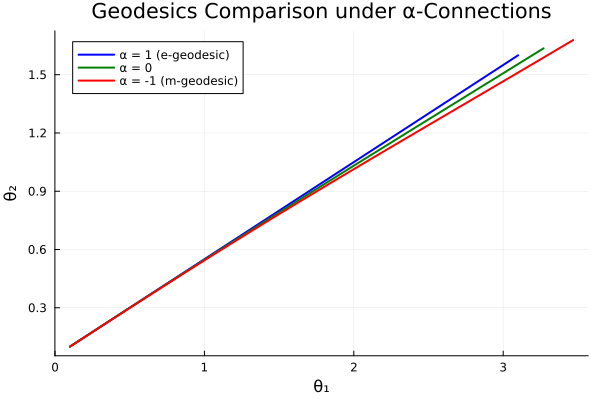

In [2]:
using LinearAlgebra
using Plots
using DifferentialEquations

# データ点: 2変数ベルヌーイの全組み合わせ
x_vals = [[0, 0], [0, 1], [1, 0], [1, 1]]

# log-partition function ψ(θ)
function ψ(theta)
    θ1, θ2, θ12 = theta
    s = 0.0
    for x in x_vals
        x1, x2 = x
        exponent = θ1 * x1 + θ2 * x2 + θ12 * x1 * x2
        s += exp(exponent)
    end
    return log(s)
end

# Hessian of ψ (Fisher情報行列の数値計算)
function hessian_ψ(theta; eps=1e-4)
    n = length(theta)
    H = zeros(n, n)
    for i in 1:n
        for j in 1:n
            e_i = zeros(n); e_i[i] = 1
            e_j = zeros(n); e_j[j] = 1
            fpp = ψ(theta .+ eps .* (e_i .+ e_j))
            fpm = ψ(theta .+ eps .* e_i .- eps .* e_j)
            fmp = ψ(theta .- eps .* e_i .+ eps .* e_j)
            fmm = ψ(theta .- eps .* (e_i .+ e_j))
            H[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps^2)
        end
    end
    return H
end

# 測地線方程式の右辺
function geodesic_rhs!(du, u, p, t)
    α = p
    θ = u[1:3]
    v = u[4:6]
    G = hessian_ψ(θ)
    Ginv = inv(G)
    acc = zeros(3)
    eps = 1e-4

    for k in 1:3
        sum_term = 0.0
        for i in 1:3
            for j in 1:3
                # ∂G_{ij}/∂θ_k の数値微分
                e_k = zeros(3); e_k[k] = 1
                G_plus = hessian_ψ(θ .+ eps .* e_k)
                G_minus = hessian_ψ(θ .- eps .* e_k)
                dG = (G_plus - G_minus) / (2 * eps)
                sum_term += dG[i, j] * v[i] * v[j]
            end
        end
        acc[k] = -0.5 * (1 - α) * sum_term
    end

    du[1:3] .= v
    du[4:6] .= acc
end

# 初期条件
θ0 = [0.1, 0.1, 0.0]
v0 = [1.0, 0.5, 0.0]
u0 = vcat(θ0, v0)
tspan = (0.0, 3.0)

# 測地線の解を得る関数
function solve_geodesic(α)
    prob = ODEProblem(geodesic_rhs!, u0, tspan, α)
    sol = solve(prob, Tsit5(), saveat=0.01)
    θ1_vals = sol[1, :]
    θ2_vals = sol[2, :]
    return θ1_vals, θ2_vals
end

# 各 α の測地線
θ1_e, θ2_e = solve_geodesic(1.0)
θ1_0, θ2_0 = solve_geodesic(0.0)
θ1_m, θ2_m = solve_geodesic(-1.0)

# プロット
plot(θ1_e, θ2_e, label="α = 1 (e-geodesic)", color=:blue, linewidth=2, grid=true)
plot!(θ1_0, θ2_0, label="α = 0", color=:green, linewidth=2)
plot!(θ1_m, θ2_m, label="α = -1 (m-geodesic)", color=:red, linewidth=2)
xlabel!("θ₁")
ylabel!("θ₂")
title!("Geodesics Comparison under α-Connections")

